In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import OneHotEncoder

# sparse_output=False: resultaat na encoding is normale NumPy array
encoder = OneHotEncoder(sparse_output=False)

# Load mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images[:, ::2, ::2]
test_images = test_images[:, ::2, ::2]

# Normalize images
train_images = train_images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0

train_images_flat = train_images.reshape(-1, 196)
test_images_flat = test_images.reshape(-1, 196)

# One hot encode labels
train_labels_oh = encoder.fit_transform(train_labels.reshape(-1, 1))
test_labels_oh = encoder.fit_transform(test_labels.reshape(-1, 1))


<function matplotlib.pyplot.show(close=None, block=None)>

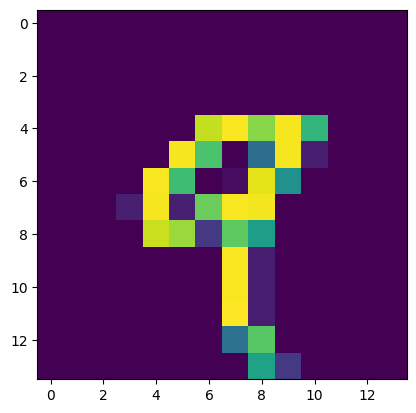

In [3]:
plt.imshow(train_images[4])
plt.show

In [4]:
print(train_images_flat.shape)
print(test_images_flat.shape)

(60000, 196)
(10000, 196)


In [5]:
def relu(arr):
    return np.maximum(0, arr)

def softmax(arr):
    arr = np.array(arr, dtype=np.float64)
    shifted = arr - np.max(arr, axis=-1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values, axis=-1, keepdims=True)

testdata = np.array([-2.0, -0.5, 0.0, 1.5, 3.0])
batch = np.array([
    [1.0, 2.0, 3.0],
    [1.0, 0.0, -1.0]
])


print(relu(testdata))
print(softmax(batch))

print("Sum of softmax outputs for each row:")
for i in range(len(batch)):
    print(f"Row {i}: {sum(softmax(batch)[i])}")


[0.  0.  0.  1.5 3. ]
[[0.09003057 0.24472847 0.66524096]
 [0.66524096 0.24472847 0.09003057]]
Sum of softmax outputs for each row:
Row 0: 0.9999999999999999
Row 1: 0.9999999999999999


In [6]:
y_true = np.array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]])
y_pred = np.array([[0.01, 0.02, 0.01, 0.05, 0.03, 0.02, 0.04, 0.75, 0.05, 0.02]])

def cross_entropy(y_true, y_predicted):
    e = 1e-9 # kleine waarde om log(0) te voorkomen
    return -np.mean(np.sum(y_true * np.log(y_predicted + e), axis=1))


ce_1 = cross_entropy(y_true, y_pred)
print(ce_1)


0.2876820711184476


In [39]:
input_nodes_amount = 196
hidden_nodes_amount = 128
output_nodes_amount = 10

W1 = np.array(np.random.randn(input_nodes_amount, hidden_nodes_amount) * 0.01, dtype="float32")
b1 = np.zeros(hidden_nodes_amount)

W2 = np.array(np.random.randn(hidden_nodes_amount, output_nodes_amount) * 0.01, dtype="float32")
b2 = np.zeros(output_nodes_amount)

In [40]:
print(f"size kb: {(W1.nbytes + W2.nbytes + b1.nbytes + b2.nbytes)/1000}")

size kb: 106.576


In [41]:
def forward(X, weight1, bias1, weight2, bias2):
    Z1 = X @ weight1 + bias1
    A1 = relu(Z1)
    Z2 = A1 @ weight2 + bias2
    A2 = softmax(Z2)
    cache = (X, Z1, A1, Z2, A2)
    return (A2, cache)

input_data = train_images_flat[:5]
actual_labels = train_labels_oh[:5]

pred, cache = forward(input_data, W1, b1, W2, b2)


print(actual_labels)
# print(pred.shape)
print(pred)
# print(cache)

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
[[0.09945647 0.10084099 0.10024733 0.0993115  0.09978129 0.09985247
  0.10021481 0.10046174 0.09977926 0.10005413]
 [0.09976188 0.10073377 0.10011879 0.09963312 0.09962955 0.09947347
  0.10027502 0.10045211 0.09948798 0.10043431]
 [0.10010308 0.09995427 0.10043405 0.10029492 0.10006178 0.09959005
  0.10005257 0.09986133 0.09962772 0.10002023]
 [0.09993406 0.10021329 0.10019296 0.09969015 0.10007132 0.10038531
  0.09985382 0.09970323 0.09963243 0.10032342]
 [0.09978418 0.10027464 0.09988582 0.10005179 0.10004817 0.09978603
  0.10023824 0.10003487 0.09974572 0.10015053]]


In [22]:
def compute_output_gradient(final_prediction, correct_answers):
    N = final_prediction.shape[0] # aantal plaatjes pet batch
    # print(f"Batch size: {N}")
    return (final_prediction - correct_answers) / N

compute_output_gradient(pred, actual_labels)

array([[ 0.02005208,  0.01998864,  0.01993723,  0.01998575,  0.01998733,
        -0.17998687,  0.02004859,  0.01994649,  0.02012443,  0.01991633],
       [-0.17993265,  0.01995112,  0.01991174,  0.02003844,  0.019987  ,
         0.0199939 ,  0.02003343,  0.02000689,  0.0200782 ,  0.01993194],
       [ 0.02003934,  0.01999762,  0.01993243,  0.02005953, -0.18002067,
         0.02001984,  0.01997503,  0.01998788,  0.0200478 ,  0.01996121],
       [ 0.01998223, -0.18003874,  0.020008  ,  0.02001792,  0.01996473,
         0.02002658,  0.02004041,  0.01996413,  0.02011075,  0.01992398],
       [ 0.0200289 ,  0.01997628,  0.01997904,  0.02005945,  0.01999961,
         0.01998539,  0.02001678,  0.01995663,  0.02008454, -0.18008662]])

In [23]:
def compute_output_gradients(hidden_output, output_gradient):
    dW2 = hidden_output.T @ output_gradient
    db2 = np.sum(output_gradient, axis=0)
    return (dW2, db2)

dw2, db2 = compute_output_gradients(cache[2], compute_output_gradient(pred, actual_labels))

print("dW2 shape:", dw2.shape)
print("db2 shape:", db2.shape)

dW2 shape: (64, 10)
db2 shape: (10,)


In [24]:
def compute_hidden_gradient(output_gradient, hidden_to_output_weights):
    return output_gradient @ hidden_to_output_weights.T

In [25]:
def relu_derivative(x):
    return (x > 0).astype(float)

In [26]:
def compute_hidden_gradients(hidden_gradient, hidden_raw_gradient, input_data):
    dZ1 = hidden_gradient * relu_derivative(hidden_raw_gradient)

    dW1 = input_data.T @ dZ1
    db1 = np.sum(dZ1, axis=0)
    return (dW1, db1)

In [14]:
def backward(y_true, cache, W2):
    # Tussenwaarden uit de forward pass uitpakken
    X, Z1, A1, Z2, A2 = cache

    # Fout bij de output: voorspelling - juiste antwoord (gemiddeld over de batch)
    output_gradient = compute_output_gradient(A2, y_true)

    # Gradient van output-gewichten W2 en bias b2
    dW2, db2 = compute_output_gradients(A1, output_gradient)

    # Foutsignaal terugsturen naar de hidden-laag via W2
    hidden_gradient = compute_hidden_gradient(output_gradient, W2)

    # Gradient van hidden-gewichten W1 en bias b1 (relu-afgeleide blokkeert inactieve nodes)
    dW1, db1 = compute_hidden_gradients(hidden_gradient, Z1, X)

    # Alle vier de gradienten teruggeven voor de update-stap
    return (dW1, db1, dW2, db2)

In [42]:
lr = 0.01
batch_size = 256
n = train_images_flat.shape[0]
epochs = 300

print(f"Number of training samples: {n}")

for epoch in range(epochs):

    # train in batches van batch_size
    for start in range(0, n, batch_size):
        b = slice(start, start + batch_size)
        voorspelling, cache = forward(train_images_flat[b], W1, b1, W2, b2)
        dW1, db1, dW2, db2 = backward(train_labels_oh[b], cache, W2)
        W1 -= lr*dW1; b1 -= lr*db1; W2 -= lr*dW2; b2 -= lr*db2

    # einde epoch: loss/acc op de hele set
    pred_all, _ = forward(train_images_flat, W1, b1, W2, b2)
    loss = cross_entropy(train_labels_oh, pred_all)
    acc = np.mean(np.argmax(pred_all, axis=1) == train_labels)
    print(f"Epoch {epoch + 1}, Loss: {loss:.4f}, Acc: {acc:.3f}")

Number of training samples: 60000
Epoch 1, Loss: 2.2932, Acc: 0.305
Epoch 2, Loss: 2.2736, Acc: 0.431
Epoch 3, Loss: 2.2245, Acc: 0.430
Epoch 4, Loss: 2.1118, Acc: 0.442
Epoch 5, Loss: 1.9049, Acc: 0.530
Epoch 6, Loss: 1.6198, Acc: 0.617
Epoch 7, Loss: 1.3413, Acc: 0.685
Epoch 8, Loss: 1.1264, Acc: 0.736
Epoch 9, Loss: 0.9708, Acc: 0.769
Epoch 10, Loss: 0.8574, Acc: 0.791
Epoch 11, Loss: 0.7731, Acc: 0.807
Epoch 12, Loss: 0.7092, Acc: 0.820
Epoch 13, Loss: 0.6598, Acc: 0.830
Epoch 14, Loss: 0.6206, Acc: 0.837
Epoch 15, Loss: 0.5888, Acc: 0.844
Epoch 16, Loss: 0.5626, Acc: 0.849
Epoch 17, Loss: 0.5405, Acc: 0.854
Epoch 18, Loss: 0.5216, Acc: 0.859
Epoch 19, Loss: 0.5052, Acc: 0.862
Epoch 20, Loss: 0.4909, Acc: 0.866
Epoch 21, Loss: 0.4783, Acc: 0.869
Epoch 22, Loss: 0.4671, Acc: 0.872
Epoch 23, Loss: 0.4570, Acc: 0.874
Epoch 24, Loss: 0.4480, Acc: 0.876
Epoch 25, Loss: 0.4397, Acc: 0.878
Epoch 26, Loss: 0.4323, Acc: 0.880
Epoch 27, Loss: 0.4254, Acc: 0.881
Epoch 28, Loss: 0.4191, Acc: 0

In [43]:
test_pred, _ = forward(test_images_flat, W1, b1, W2, b2)

test_loss = cross_entropy(test_labels_oh, test_pred)
test_acc = np.mean(np.argmax(test_pred, axis=1) == test_labels)

print("Final evaluation:")
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.3f}")

Final evaluation:
Test loss: 0.1592, Test accuracy: 0.953


In [44]:
# Export weights
destination = input("Desitination path")
np.save(destination + "W1.npy", W1, True)
np.save(destination + "b1.npy", b1, True)
np.save(destination + "W2.npy", W2, True)
np.save(destination + "b2.npy", b2, True)